# Empresa Aliada Entregable IV

In [3]:
#Partir del codigo del entregable pasado


In [4]:
#Cargar todos los archivos con los que vamos a trabajar 
"""Primero converti todos los archivos a .csv desde Excel""" 
import pandas as pd 
category = pd.read_csv("DIM_CATEGORY.csv") 
product = pd.read_csv("DIM_PRODUCT.csv") 
segment = pd.read_csv("DIM_SEGMENT.csv") 
calendar = pd.read_csv("DIM_CALENDAR.csv") 
sales = pd.read_csv("FACT_SALES.csv") 

#REVISAR NULOS Y DUPLICADOS 
#Valores nulos 
print("Valores nulos por tabla:") 
print(category.isnull().sum()) 
print(product.isnull().sum()) 
print(segment.isnull().sum()) 
print(calendar.isnull().sum()) 
print(sales.isnull().sum()) 

#Eliminar Duplicados 
category = category.drop_duplicates() 
product = product.drop_duplicates() 
segment = segment.drop_duplicates() 
alendar = calendar.drop_duplicates() 
sales = sales.drop_duplicates() 

# FACT_SALES + DIM_CALENDAR
sales_calendar = sales.merge(
    calendar,
    on="WEEK",
    how="left"
)

# DIM_PRODUCT + DIM_CATEGORY
# Asegurar que CATEGORY sea string en ambas tablas
product["CATEGORY"] = product["CATEGORY"].astype(str)
category["ID_CATEGORY"] = category["ID_CATEGORY"].astype(str)

prod_cat = product.merge(
    category,
    left_on="CATEGORY",     # columna en dim_product
    right_on="ID_CATEGORY", # columna en dim_category
    how="left"
)

# DIM_PRODUCT + DIM_SEGMENT
# (sin CATEGORY, solo ATTR1-3 y FORMAT)
prod_seg = product.merge(
    segment,
    on=["ATTR1", "ATTR2", "ATTR3", "FORMAT"],
    how="left"
)

# DIM_PRODUCT + DIM_CATEGORY + DIM_SEGMENT
prod_cat_seg = product.merge(
    category,
    left_on="CATEGORY",
    right_on="ID_CATEGORY",
    how="left"
).merge(
    segment,
    on=["ATTR1", "ATTR2", "ATTR3", "FORMAT"],
    how="left"
)




Valores nulos por tabla:
ID_CATEGORY    0
CATEGORY       0
dtype: int64
MANUFACTURER        0
BRAND               0
ITEM                2
ITEM_DESCRIPTION    0
CATEGORY            0
FORMAT              0
ATTR1               6
ATTR2               0
ATTR3               6
dtype: int64
CATEGORY    0
ATTR1       0
ATTR2       0
ATTR3       1
FORMAT      0
SEGMENT     0
dtype: int64
WEEK           0
YEAR           0
MONTH          0
WEEK_NUMBER    0
DATE           0
dtype: int64
WEEK                           0
ITEM_CODE                      0
TOTAL_UNIT_SALES               0
TOTAL_VALUE_SALES              0
TOTAL_UNIT_AVG_WEEKLY_SALES    0
REGION                         0
dtype: int64


## ENTREGABLE EMPRESA ALIADA IV

Determinar variables relevantes:
- Total Sales es la variable objetivo
- Category, product, segment, region son variables categoricas
- Week, month, year, variables temporales

### DETERMINAR VARIABLES RELEVANTES

In [5]:
#Seleccionar solo columnas numéricas
numeric_cols = sales_calendar.select_dtypes(include='number')
print(numeric_cols.columns)

#Calcular correlación solo entre numéricas
corr = numeric_cols.corr()
display(corr)

#Estadísticas descriptivas de las variables numéricas
display(numeric_cols.describe())

#Identificar posibles variables clave
if 'Total Sales' in numeric_cols.columns:
    corr_target = corr['Total Sales'].sort_values(ascending=False)
    print("\nCorrelación de cada variable con Total Sales:")
    display(corr_target)


Index(['TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES',
       'YEAR', 'MONTH', 'WEEK_NUMBER'],
      dtype='str')


,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,YEAR,MONTH,WEEK_NUMBER
TOTAL_UNIT_SALES,1.000000,0.916252,0.426035,0.006414,0.002639,0.001002
TOTAL_VALUE_SALES,0.916252,1.000000,0.367367,0.016943,0.003579,0.002070
TOTAL_UNIT_AVG_WEEKLY_SALES,0.426035,0.367367,1.000000,-0.002713,-0.002254,-0.005718
YEAR,0.006414,0.016943,-0.002713,1.000000,-0.356890,-0.386548
MONTH,0.002639,0.003579,-0.002254,-0.356890,1.000000,0.920508
WEEK_NUMBER,0.001002,0.002070,-0.005718,-0.386548,0.920508,1.000000


,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,YEAR,MONTH,WEEK_NUMBER
count,122002.000000,122002.000000,122002.000000,122002.000000,122002.000000,122002.000000
mean,3.211097,90.513761,10.099904,2022.334396,5.531729,22.141194
std,14.496009,350.236505,22.650142,0.471781,3.214612,14.134943
min,0.000000,0.001000,0.042000,2022.000000,1.000000,1.000000
25%,0.063000,2.662000,2.316000,2022.000000,3.000000,10.000000
50%,0.367000,16.812000,3.993500,2022.000000,5.000000,20.000000
75%,1.520000,62.961500,8.898000,2023.000000,8.000000,32.000000
max,504.681000,12236.759000,794.000000,2023.000000,12.000000,52.000000


### GRAFICOS DE DISTRIBUCION

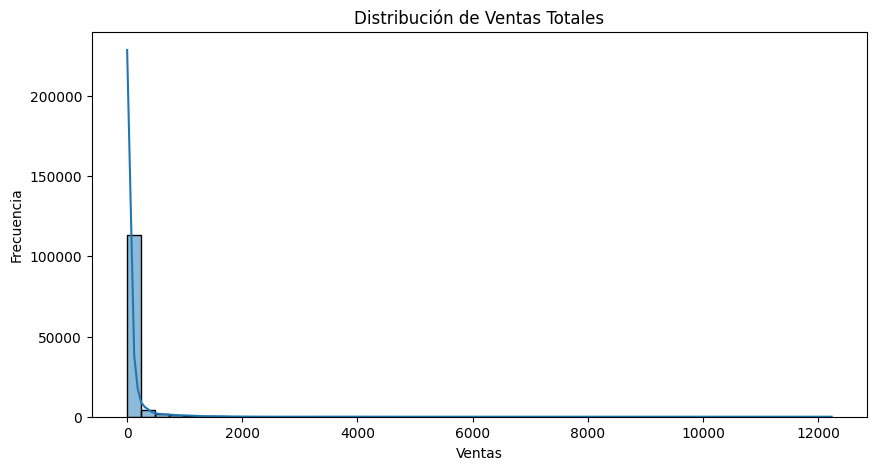

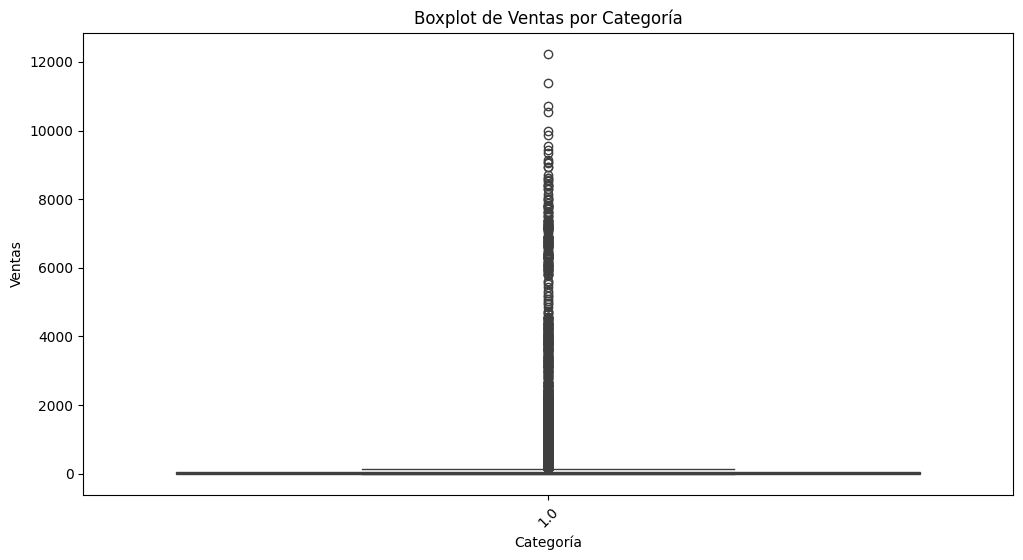

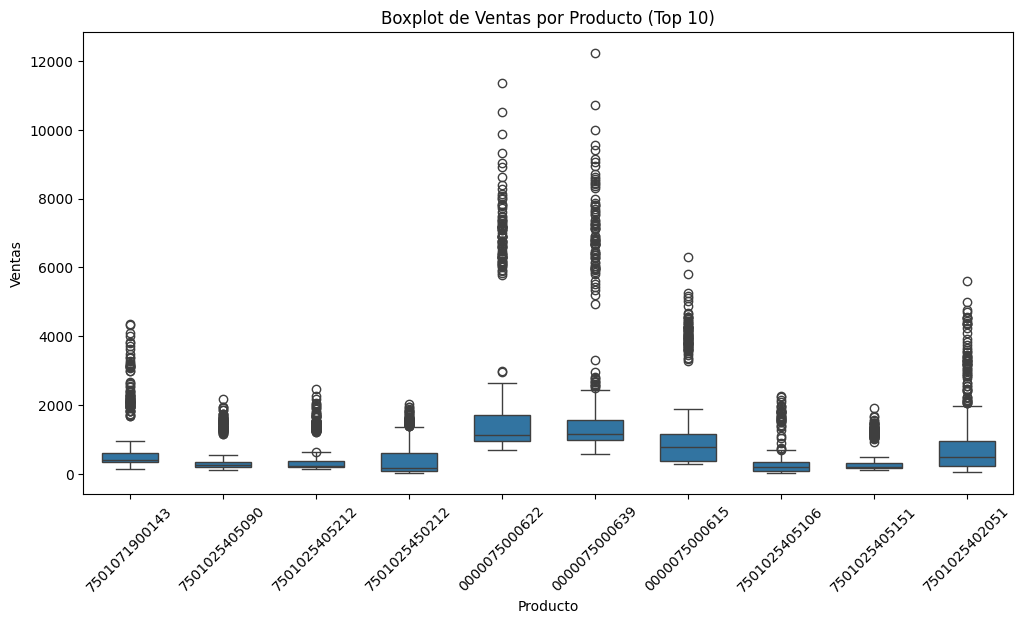

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de ventas totales
plt.figure(figsize=(10,5))
sns.histplot(sales['TOTAL_VALUE_SALES'], bins=50, kde=True)
plt.title("Distribución de Ventas Totales")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot de ventas por categoría
if 'CATEGORY' in prod_cat_seg.columns:
    sales_cat = sales.merge(
        prod_cat_seg[['ITEM','CATEGORY']],
        left_on='ITEM_CODE',
        right_on='ITEM',
        how='left'
    )
    
    plt.figure(figsize=(12,6))
    sns.boxplot(x='CATEGORY', y='TOTAL_VALUE_SALES', data=sales_cat)
    plt.title("Boxplot de Ventas por Categoría")
    plt.xticks(rotation=45)
    plt.xlabel("Categoría")
    plt.ylabel("Ventas")
    plt.show()

# Boxplot de ventas por producto (Top 10)
# Top 10 productos por ventas totales
top_products = sales.groupby('ITEM_CODE')['TOTAL_VALUE_SALES'].sum().sort_values(ascending=False).head(10).index
sales_top10 = sales[sales['ITEM_CODE'].isin(top_products)]

plt.figure(figsize=(12,6))
sns.boxplot(x='ITEM_CODE', y='TOTAL_VALUE_SALES', data=sales_top10, width=0.6, showfliers=True)
plt.title("Boxplot de Ventas por Producto (Top 10)")
plt.xticks(rotation=45)
plt.xlabel("Producto")
plt.ylabel("Ventas")
plt.show()


In [7]:
#Generamos un histograma de ventas totales
#Generamos un boxplot de ventas por categoría
#Generó un boxplot de ventas por producto

In [8]:
#OBSERVACIONES
#La info de esta empresa aliada no esta del todo bien hecha, hay que hacerle muchas mejoras
#para poder trabajar con mejor facilidad y realizar graficos y analisis mas especificos o claros

### FILTRAR VENTAS POR PRODUCTO, REGION O SEGMENTO

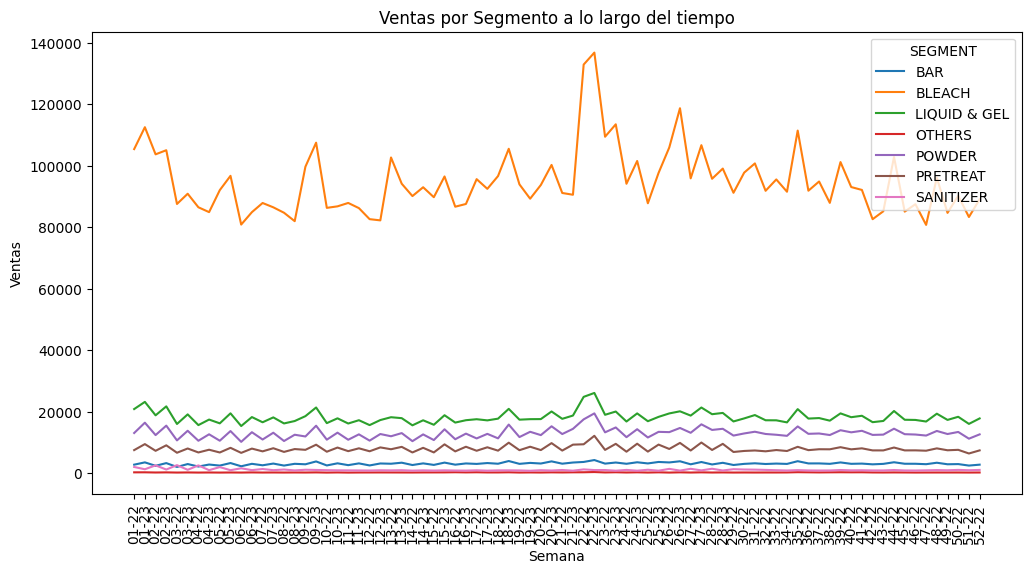

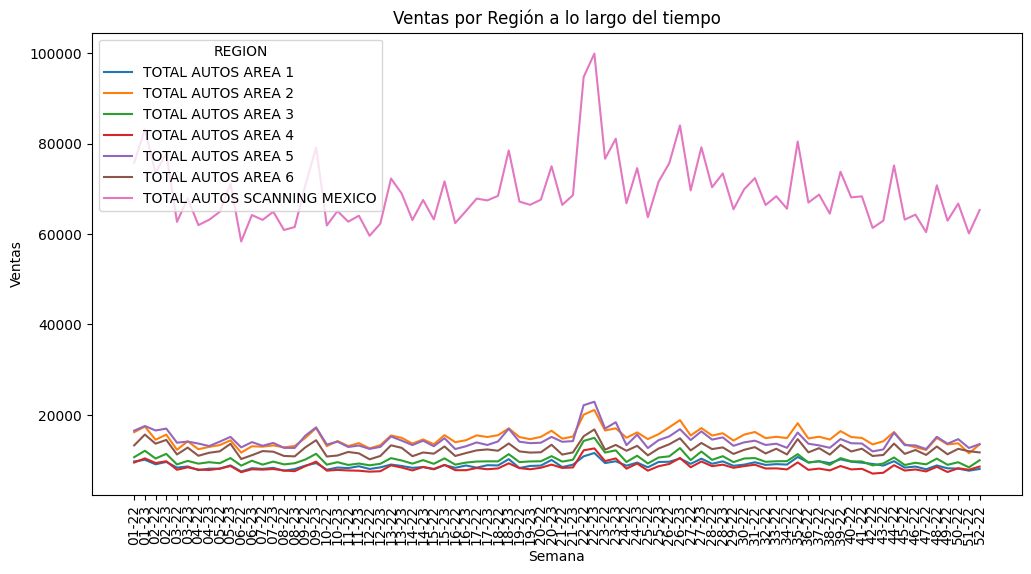

In [9]:
# Merge con segmento y categoría
sales_full = sales.merge(
    prod_cat_seg[['ITEM','CATEGORY','SEGMENT']],
    left_on='ITEM_CODE',
    right_on='ITEM',
    how='left'
)

# Ventas por segmento a lo largo del tiempo (usando WEEK)
sales_seg_time = sales_full.groupby(['WEEK','SEGMENT'])['TOTAL_VALUE_SALES'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=sales_seg_time, x='WEEK', y='TOTAL_VALUE_SALES', hue='SEGMENT')
plt.title("Ventas por Segmento a lo largo del tiempo")
plt.xlabel("Semana")
plt.ylabel("Ventas")
plt.xticks(rotation=90)
plt.show()

# Ventas por región a lo largo del tiempo
if 'REGION' in sales.columns:
    sales_region_time = sales.groupby(['WEEK','REGION'])['TOTAL_VALUE_SALES'].sum().reset_index()
    
    plt.figure(figsize=(12,6))
    sns.lineplot(data=sales_region_time, x='WEEK', y='TOTAL_VALUE_SALES', hue='REGION')
    plt.title("Ventas por Región a lo largo del tiempo")
    plt.xlabel("Semana")
    plt.ylabel("Ventas")
    plt.xticks(rotation=90)
    plt.show()


### SCATTER PLOTS PARA RELACIONES CLAVE

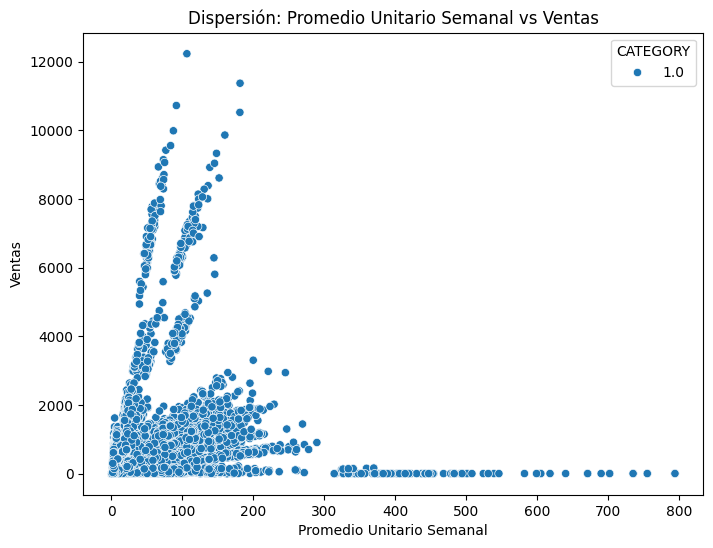

In [10]:
# relación entre ventas y promedio semanal por unidad
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='TOTAL_UNIT_AVG_WEEKLY_SALES',
    y='TOTAL_VALUE_SALES',
    data=sales_full,
    hue='CATEGORY'
)
plt.title("Dispersión: Promedio Unitario Semanal vs Ventas")
plt.xlabel("Promedio Unitario Semanal")
plt.ylabel("Ventas")
plt.show()


### GRAFICA BARRAS APILADAS

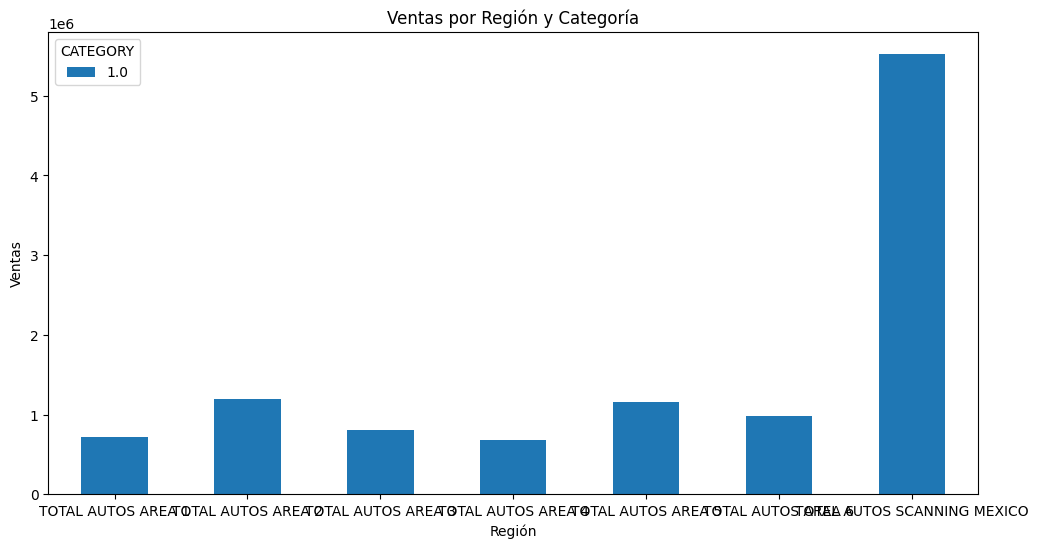

In [11]:
if 'REGION' in sales_full.columns and 'CATEGORY' in sales_full.columns:
    region_cat_grouped = sales_full.groupby(['REGION','CATEGORY'])['TOTAL_VALUE_SALES'].sum().unstack()
    
    region_cat_grouped.plot(kind='bar', stacked=True, figsize=(12,6))
    plt.title("Ventas por Región y Categoría")
    plt.ylabel("Ventas")
    plt.xlabel("Región")
    plt.xticks(rotation=0)
    plt.show()


### A MANERA DE CIERRE...
El analisis se complica un poco porque los datos no estan del todo exactos o bien estructurados, se hizo lo mejor que se pudo con lo que se tiene, aplicando los conocimientos que se han ido adquiriendo.

Es interesante ver como se van mostrando los datos en las distintas tablas, asi se puede comprender mejor que es lo que esta ocurriendo a "nivel global" hablando sobre como va en ventas la empresa

In [12]:
'''GUARDADO DE ARCHIVOS CSV MANIPULADOS PARA ANALISIS DE FORECASTING'''
from pathlib import Path

# Carpeta EmpresaAliada donde está guardado el notebook
carpeta_proyecto = Path.cwd()

# Carpeta para los archivos procesados
carpeta_procesados = carpeta_proyecto / "datos_procesados"
carpeta_procesados.mkdir(exist_ok=True)

# Corrige el detalle del notebook IV y elimina duplicados
calendar = calendar.drop_duplicates()

# DataFrames creados durante el notebook IV
tablas = {
    "DIM_CATEGORY_limpio.csv": "category",
    "DIM_PRODUCT_limpio.csv": "product",
    "DIM_SEGMENT_limpio.csv": "segment",
    "DIM_CALENDAR_limpio.csv": "calendar",
    "FACT_SALES_limpio.csv": "sales",
    "VENTAS_CON_CALENDARIO.csv": "sales_calendar",
    "PRODUCTO_CATEGORIA.csv": "prod_cat",
    "PRODUCTO_SEGMENTO.csv": "prod_seg",
    "PRODUCTO_CATEGORIA_SEGMENTO.csv": "prod_cat_seg",
    "VENTAS_COMPLETAS.csv": "sales_full"
}

for nombre_archivo, nombre_dataframe in tablas.items():
    if nombre_dataframe in globals():
        dataframe = globals()[nombre_dataframe]
        ruta = carpeta_procesados / nombre_archivo

        dataframe.to_csv(
            ruta,
            index=False,
            encoding="utf-8-sig"
        )

        print(f"Guardado: {nombre_archivo}")
    else:
        print(f"No se guardó {nombre_archivo}: falta ejecutar la celda que crea '{nombre_dataframe}'.")

print("\nArchivos procesados guardados en:")
print(carpeta_procesados)

Guardado: DIM_CATEGORY_limpio.csv
Guardado: DIM_PRODUCT_limpio.csv
Guardado: DIM_SEGMENT_limpio.csv
Guardado: DIM_CALENDAR_limpio.csv
Guardado: FACT_SALES_limpio.csv
Guardado: VENTAS_CON_CALENDARIO.csv
Guardado: PRODUCTO_CATEGORIA.csv
Guardado: PRODUCTO_SEGMENTO.csv
Guardado: PRODUCTO_CATEGORIA_SEGMENTO.csv
Guardado: VENTAS_COMPLETAS.csv

Archivos procesados guardados en:
/Users/soma/Documents/Visual Studio Code/study/python_ebac/EmpresaAliada/datos_procesados
